In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

In [17]:
# Important libraries for running in jupyter notebook
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
# from keras.layers.convolutional import Conv2D  #OLD
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
# from keras.utils import np_utils   #OLD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

"""" Below was used by Colab
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
# from keras.layers.convolutional import Conv2D  #OLD
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
# from keras.utils import np_utils   #OLD
from keras.utils import to_categorical
from keras import backend as K
"""


'" Below was used by Colab\nfrom keras.models import Sequential\nfrom keras.layers import Dense\nfrom keras.layers import Dropout\nfrom keras.layers import Flatten\n# from keras.layers.convolutional import Conv2D  #OLD\nfrom keras.layers import Conv2D\nfrom keras.layers import MaxPooling2D\n# from keras.utils import np_utils   #OLD\nfrom keras.utils import to_categorical\nfrom keras import backend as K\n'

In [18]:
# Sample Code Learning: # one hot encode
y_train = np.array([4, 0, 3, 2])
print(y_train)
print('y_train.shape:',y_train.shape)
# Y_train = np_utils.to_categorical(y_train)  #OLD
Y_train = to_categorical(y_train)
print(Y_train)
Y_train.shape
print('Y_train.shape:',Y_train.shape)

[4 0 3 2]
y_train.shape: (4,)
[[0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]]
Y_train.shape: (4, 5)


Example from the MNIST database

In [19]:
import keras
from keras.datasets import mnist

#(x_train,y_train),(x_test,y_test)=mnist.load_data()

#print('x_train.shape:',x_train.shape)
#print('y_train.shape:',y_train.shape)
#print('x_test.shape:',x_test.shape)
#print('y_test.shape:',y_test.shape)

#aa=x_train[0]
#print('shape of x_train[0]:',aa.shape)

#print('x_train[0]:')
#print(x_train[0]) # To show the first image of (28,28) in x_train
#print('y_train[0:4]:') # To show 4 labels in y_train
#y_train[0:4]
#------------------------------------------------------------
print('---------------------------------------------------')
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape      # (60000, 28, 28)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)
print(x_train.shape[0], 'train samples') #60000 train samples
print(x_test.shape[0], 'test samples')

print(x_train[0]) # To show the first image of (28,28) in x_train

---------------------------------------------------
x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
60000 train samples
10000 test samples
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        

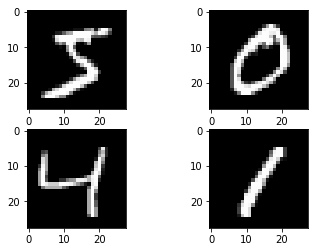

In [21]:
plt.subplot(221)
plt.imshow(x_train[0], cmap=plt.get_cmap('gray'))
plt.subplot(222)
plt.imshow(x_train[1], cmap=plt.get_cmap('gray'))
plt.subplot(223)
plt.imshow(x_train[2], cmap=plt.get_cmap('gray'))
plt.subplot(224)
plt.imshow(x_train[3], cmap=plt.get_cmap('gray'))
# show the plot
plt.show()

In [25]:
# Artificial Neural Network for MNIST

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

# reshape to be [samples][pixels][width][height]
X_train = x_train.reshape(x_train.shape[0], 1, 28, 28).astype('float32')
X_test = x_test.reshape(x_test.shape[0], 1, 28, 28).astype('float32')
print('X_train.shape:',X_train.shape)
print('X_test.shape:',X_test.shape)
print('original label')
print(y_train)
print('y_train.shape:',y_train.shape)

# labels are changed a one_hot representation.
Y_train = to_categorical(y_train)
print('new label')
print(Y_train)
Y_train.shape
print('Y_train.shape:',Y_train.shape)

Y_test = to_categorical(y_test)
num_classes = Y_test.shape[1]


X_train.shape: (60000, 1, 28, 28)
X_test.shape: (10000, 1, 28, 28)
original label
[5 0 4 ... 5 6 8]
y_train.shape: (60000,)
new label
[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
Y_train.shape: (60000, 10)


X_train.shape before reshape (60000, 28, 28)
X_train.shape after reshape (60000, 784)
Epoch 1/25
300/300 - 2s - loss: 0.2970 - accuracy: 0.9162 - val_loss: 0.1511 - val_accuracy: 0.9556
Epoch 2/25
300/300 - 1s - loss: 0.1192 - accuracy: 0.9660 - val_loss: 0.1033 - val_accuracy: 0.9692
Epoch 3/25
300/300 - 1s - loss: 0.0773 - accuracy: 0.9776 - val_loss: 0.0828 - val_accuracy: 0.9754
Epoch 4/25
300/300 - 1s - loss: 0.0554 - accuracy: 0.9841 - val_loss: 0.0720 - val_accuracy: 0.9773
Epoch 5/25
300/300 - 1s - loss: 0.0415 - accuracy: 0.9880 - val_loss: 0.0656 - val_accuracy: 0.9790
Epoch 6/25
300/300 - 1s - loss: 0.0314 - accuracy: 0.9913 - val_loss: 0.0667 - val_accuracy: 0.9792
Epoch 7/25
300/300 - 1s - loss: 0.0230 - accuracy: 0.9944 - val_loss: 0.0590 - val_accuracy: 0.9814
Epoch 8/25
300/300 - 1s - loss: 0.0177 - accuracy: 0.9957 - val_loss: 0.0671 - val_accuracy: 0.9783
Epoch 9/25
300/300 - 1s - loss: 0.0136 - accuracy: 0.9969 - val_loss: 0.0690 - val_accuracy: 0.9781
Epoch 10/25
30

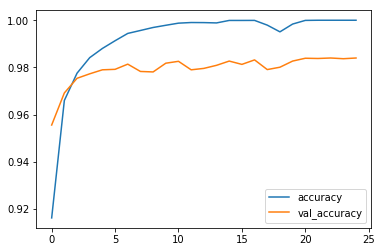

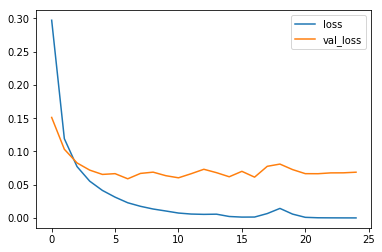

In [26]:
# EXAMPLE 1:
# ANN example based on 784 (28x28) inputs, 1D input
#
from keras.datasets import mnist

# load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)
#
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
#
# flatten 28*28 images to a 784 vector for each image
print('X_train.shape before reshape' , X_train.shape)
num_pixels = X_train.shape[1] * X_train.shape[2]

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32')
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32')

print('X_train.shape after reshape' , X_train.shape)

# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]
num_hidden_nodes = 650

# define baseline model
# Dense : a regular fully connected layer
# The chosen complie model has a loss function, and the purpose is to compute the quantity that
# the model should minimize during training.  Below, the 'categorical_crossentropy' is used as
# the loss function. (The MSE is not chosen to be the loss function.) It would compute the crossentropy
# loss between the labels and predictions. There are two or more label classes, usually with labels
# provided in a one_hot representation.

def baseline_model():
    # create model
    model = Sequential()
    model.add(Dense(num_hidden_nodes, input_dim=num_pixels, kernel_initializer='normal', activation='relu'))
    model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    # Choice of optimizer: adam (adaptive moment estimation), AdaGrad (adaptive learning rate),
    # sgd (Stochastic gradient descent), RMSprop (similar to AdaGrad), Adadelta (adaptive delta) ...
    return model
# build the model
model = baseline_model()
# Fit the model
# verbose : number of steps before showing a result
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=200, verbose=2)
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Error: %.2f%%" % (100-scores[1]*100))
#
metrics = history.history
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

In [30]:
# EXAMPLE 2:
# The example based on a simple CNN structure, 2D input
# jupyter code:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

seed = 7
np.random.seed(seed)
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][pixels][width][height]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]

# define baseline model
def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv2D(32, (5, 5), input_shape=(28, 28,1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model
#
# build the model
model = baseline_model()
# Fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# Final evaluation of the model

scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))
#

Epoch 1/10
300/300 - 8s - loss: 0.2463 - accuracy: 0.9295 - val_loss: 0.0761 - val_accuracy: 0.9772
Epoch 2/10
300/300 - 8s - loss: 0.0717 - accuracy: 0.9786 - val_loss: 0.0492 - val_accuracy: 0.9836
Epoch 3/10
300/300 - 8s - loss: 0.0527 - accuracy: 0.9845 - val_loss: 0.0460 - val_accuracy: 0.9850
Epoch 4/10
300/300 - 8s - loss: 0.0405 - accuracy: 0.9874 - val_loss: 0.0376 - val_accuracy: 0.9877
Epoch 5/10
300/300 - 8s - loss: 0.0326 - accuracy: 0.9897 - val_loss: 0.0448 - val_accuracy: 0.9858
Epoch 6/10
300/300 - 8s - loss: 0.0285 - accuracy: 0.9911 - val_loss: 0.0346 - val_accuracy: 0.9883
Epoch 7/10
300/300 - 8s - loss: 0.0244 - accuracy: 0.9924 - val_loss: 0.0339 - val_accuracy: 0.9886
Epoch 8/10
300/300 - 8s - loss: 0.0195 - accuracy: 0.9935 - val_loss: 0.0362 - val_accuracy: 0.9888
Epoch 9/10
300/300 - 8s - loss: 0.0166 - accuracy: 0.9945 - val_loss: 0.0356 - val_accuracy: 0.9895
Epoch 10/10
300/300 - 8s - loss: 0.0154 - accuracy: 0.9949 - val_loss: 0.0350 - val_accuracy: 0.9882

In [28]:
# EXAMPLE 3:
# The example based on another simple CNN structure, 2D input
#
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

seed = 7
np.random.seed(seed)
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][pixels][width][height]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255
# one hot encode outputs
y_train =  to_categorical(y_train)
y_test =  to_categorical(y_test)
num_classes = y_test.shape[1]
#

def baseline_model():
	# create model
	model = Sequential()
	model.add(Conv2D(64, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
	model.add(MaxPooling2D(pool_size=(2, 2)))
	model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
	model.add(MaxPooling2D(pool_size=(2, 2)))
	model.add(Dropout(0.25))
	model.add(Flatten())
	model.add(Dense(128, activation='relu'))
	model.add(Dropout(0.5))
	model.add(Dense(num_classes, activation='softmax'))
	# Compile model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

model = baseline_model()
# Fit the model
model.fit(x=X_train, y=y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


Epoch 1/10
300/300 - 17s - loss: 0.4353 - accuracy: 0.8648 - val_loss: 0.0775 - val_accuracy: 0.9752
Epoch 2/10
300/300 - 17s - loss: 0.1316 - accuracy: 0.9606 - val_loss: 0.0475 - val_accuracy: 0.9844
Epoch 3/10
300/300 - 17s - loss: 0.0973 - accuracy: 0.9708 - val_loss: 0.0368 - val_accuracy: 0.9875
Epoch 4/10
300/300 - 16s - loss: 0.0816 - accuracy: 0.9756 - val_loss: 0.0334 - val_accuracy: 0.9882
Epoch 5/10
300/300 - 17s - loss: 0.0684 - accuracy: 0.9790 - val_loss: 0.0328 - val_accuracy: 0.9894
Epoch 6/10
300/300 - 17s - loss: 0.0643 - accuracy: 0.9807 - val_loss: 0.0295 - val_accuracy: 0.9894
Epoch 7/10
300/300 - 16s - loss: 0.0562 - accuracy: 0.9833 - val_loss: 0.0251 - val_accuracy: 0.9913
Epoch 8/10
300/300 - 17s - loss: 0.0532 - accuracy: 0.9839 - val_loss: 0.0259 - val_accuracy: 0.9909
Epoch 9/10
300/300 - 17s - loss: 0.0494 - accuracy: 0.9843 - val_loss: 0.0235 - val_accuracy: 0.9919
Epoch 10/10
300/300 - 17s - loss: 0.0463 - accuracy: 0.9859 - val_loss: 0.0236 - val_accura

aa =  [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
a =  [[ 1  2  3  4  5  6  7  8]
 [ 1  4  8 14 12  7  3  2]]


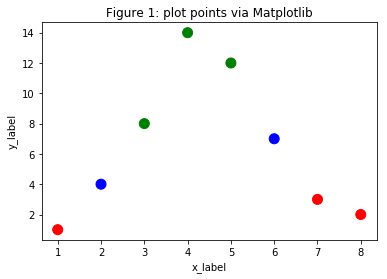

In [5]:
# DEMO of python plotting
#
from numpy import arange

# To create an array from 0.5 to 5.5 in step of 0.5
aa = arange(0.5, 5.5, 0.5)
print('aa = ',aa)

# To create a 2D array
a = np.array([[1, 2, 3, 4, 5, 6, 7, 8],
              [1, 4, 8, 14, 12, 7, 3, 2]])

print('a = ',a)
categories = np.array([0, 2, 1, 1, 1, 2, 0, 0])

colormap = np.array(['r', 'g', 'b'])

plt.scatter(a[0], a[1], s=100, c=colormap[categories])
# s=area of the circular dots
plt.title('Figure 1: plot points via Matplotlib')
plt.xlabel('x_label')
plt.ylabel('y_label')

plt.savefig('ScatterClassPlot.jpg')
plt.show()  # to show the Figure

END OF FILE